# Historical FPC: monthly climatology versus annual output, 1971–2000

This notebook tests whether `fpc1971to2000.txt` is the arithmetic annual mean of the monthly FPC output in `mfpc_pft_avg_1971_2000.out`.

It deliberately tests two competing interpretations:

1. **Monthly annual mean**: average each calendar month over 1971–2000, then average the 12 monthly climatological values.
2. **Climatological maximum**: take the maximum of the 12 monthly climatological values.

These are compared with the supplied annual file using tables, error metrics, and signed-difference maps. The sample supplied with the request suggests the annual file may be much closer to peak growing-season FPC than to the 12-month mean, particularly for deciduous vegetation, grasses, and moss. The notebook determines whether that is true across all grid cells.

### 👉 Conclusion
The result is actually very clear: `fpc1971to2000.txt` is not a calendar annual mean of the monthly FPC values. It behaves much more like a peak growing-season diagnostic.



## Context & Methods

### Why the two files may legitimately differ

The successful future check averaged **annual LPJ-GUESS output over years**. This historical check instead averages **monthly states over months and years**. Those operations only reproduce the annual file if the annual diagnostic is itself defined as the mean of the 12 monthly states.

The supplied example is strongly seasonal. At `(63.25, 58.75)` in 1971, `Total` averages approximately 0.421 across the 12 displayed months and reaches 0.678 in summer, whereas the supplied 1971–2000 annual file reports 0.665. This is suggestive—not conclusive, because one year is being compared with a 30-year climatology—but it makes an annual/peak-state diagnostic plausible.

### Key assumptions

- The comparison period is 1971–2000 inclusive.
- `mfpc_pft_avg_1971_2000.out` contains one record per coordinate, year, and month.
- Repeated header rows are formatting artifacts and must be removed.
- `Natural_sum` is the sum of the 16 natural PFT columns; `Peatland_sum` is the sum of the seven peatland PFT columns.
- `Total` is read directly rather than reconstructed because the README states that land-cover fractions enter its definition.
- A difference is defined as **monthly-derived statistic minus supplied annual value**.


In [12]:
from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 12,
})

try:
    import cartopy.crs as ccrs
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False

DATA_DIR = Path("~/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS").expanduser()
MONTHLY_FILE = DATA_DIR / "mfpc_pft_avg_1971_2000.out"
ANNUAL_FILE = DATA_DIR / "fpc1971to2000.txt"

# Also find the files if the notebook is run from the parent of an upload folder.
if not MONTHLY_FILE.exists() and (Path("upload") / MONTHLY_FILE.name).exists():
    MONTHLY_FILE = Path("upload") / MONTHLY_FILE.name
if not ANNUAL_FILE.exists() and (Path("upload") / ANNUAL_FILE.name).exists():
    ANNUAL_FILE = Path("upload") / ANNUAL_FILE.name

START_YEAR, END_YEAR = 1971, 2000
EXPECTED_YEARS = END_YEAR - START_YEAR + 1
CHUNKSIZE = 250_000
MAP_FIELDS = ["Total", "Natural_sum", "Peatland_sum"]
EXAMPLE_FIELDS = ["IBS", "C3G", "pmoss"]
SAVE_FIGURES = True
FIGURE_DIR = Path("06-original_vs_monthly_comparison_figures/historical_comparison")
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(exist_ok=True)

NATURAL_PFTS = [
    "BNE", "BINE", "BNS", "TeNE", "TeBE", "IBS", "TeBS", "C3G",
    "HSE", "HSS", "LSE", "LSS", "GRT", "EPDS", "SPDS", "CLM",
]
PEATLAND_PFTS = ["pLSE", "pLSS", "pCLM", "WetGRS", "pmoss", "C3G_wet", "C4G_wet"]
KEYS = ["Lon", "Lat"]

print(f"Monthly file: {MONTHLY_FILE}")
print(f"Annual file:  {ANNUAL_FILE}")
print(f"Cartopy available: {HAS_CARTOPY}")
assert MONTHLY_FILE.exists(), (
    "Monthly file not found. Put mfpc_pft_avg_1971_2000.out beside this notebook "
    "or edit MONTHLY_FILE above."
)
assert ANNUAL_FILE.exists(), "Annual reference file not found; edit ANNUAL_FILE above."


Monthly file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/mfpc_pft_avg_1971_2000.out
Annual file:  /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/fpc1971to2000.txt
Cartopy available: True


## Data

### 1. Aggregate the large monthly file safely

The loader processes the file in chunks. It removes repeated headers, selects 1971–2000, and accumulates sums and counts by (Lon, Lat, Month). Only the compact 12-month climatology is retained in memory.


In [13]:
def monthly_climatology_from_large_file(path, start_year, end_year, chunksize=250_000):
    header = pd.read_csv(path, sep=r"\s+", nrows=0).columns.tolist()
    required = {"Lon", "Lat", "Year", "Month", "Total"}
    missing = required.difference(header)
    if missing:
        raise ValueError(f"Missing required monthly columns: {sorted(missing)}")

    value_columns = [column for column in header if column not in ["Lon", "Lat", "Year", "Month"]]
    sum_parts, count_parts = [], []
    repeated_headers = 0

    for raw in pd.read_csv(path, sep=r"\s+", dtype=str, chunksize=chunksize):
        header_rows = raw["Year"].eq("Year")
        repeated_headers += int(header_rows.sum())
        raw = raw.loc[~header_rows].copy()
        raw["Year"] = pd.to_numeric(raw["Year"], errors="coerce")
        raw = raw.loc[raw["Year"].between(start_year, end_year)].copy()
        if raw.empty:
            continue

        numeric_columns = ["Lon", "Lat", "Month"] + value_columns
        raw[numeric_columns] = raw[numeric_columns].apply(pd.to_numeric, errors="coerce")
        if raw[numeric_columns].isna().any().any():
            bad = raw.loc[raw[numeric_columns].isna().any(axis=1)].head()
            raise ValueError(f"Non-numeric or missing monthly values found:\n{bad}")

        grouped = raw.groupby(["Lon", "Lat", "Month"])[value_columns]
        sum_parts.append(grouped.sum())
        count_parts.append(grouped.count())

    if not sum_parts:
        raise ValueError(f"No records found for {start_year}–{end_year} in {path}")

    sums = pd.concat(sum_parts).groupby(level=[0, 1, 2]).sum()
    counts = pd.concat(count_parts).groupby(level=[0, 1, 2]).sum()
    climatology = (sums / counts).reset_index()
    return climatology, counts.reset_index(), repeated_headers, value_columns


monthly_climatology, monthly_counts, headers_removed, monthly_fields = (
    monthly_climatology_from_large_file(MONTHLY_FILE, START_YEAR, END_YEAR, CHUNKSIZE)
)
annual_reference = pd.read_csv(ANNUAL_FILE, sep=r"\s+")

print(f"Repeated header rows removed after the first header: {headers_removed:,}")
print(f"Monthly-climatology rows: {len(monthly_climatology):,}")
print(f"Annual-reference rows: {len(annual_reference):,}")


Repeated header rows removed after the first header: 0
Monthly-climatology rows: 200,568
Annual-reference rows: 16,750


### 2. Validate coverage and derive comparable fields

Every coordinate–month combination should contain 30 annual samples. The notebook also checks months 1–12, duplicate coordinates in the annual file, coordinate-set overlap and an audit of unmatched coordinates, and column availability.

The numerical comparison uses only coordinates present in both files. Unmatched cells are not filled, interpolated, or treated as zero.


In [14]:
count_values = monthly_counts[monthly_fields].to_numpy()
assert np.all(count_values == EXPECTED_YEARS), (
    "Some coordinate–month–field combinations do not contain exactly 30 values. "
    "Inspect monthly_counts before interpreting the comparison."
)
assert set(monthly_climatology["Month"].unique()) == set(range(1, 13))
assert not annual_reference.duplicated(KEYS).any(), "Duplicate coordinates in annual file."

missing_natural = set(NATURAL_PFTS).difference(monthly_climatology.columns)
missing_peatland = set(PEATLAND_PFTS).difference(monthly_climatology.columns)
assert not missing_natural, f"Missing natural PFTs: {sorted(missing_natural)}"
assert not missing_peatland, f"Missing peatland PFTs: {sorted(missing_peatland)}"

monthly_climatology["Natural_sum"] = monthly_climatology[NATURAL_PFTS].sum(axis=1)
monthly_climatology["Peatland_sum"] = monthly_climatology[PEATLAND_PFTS].sum(axis=1)

comparison_fields = [
    field for field in NATURAL_PFTS + PEATLAND_PFTS + ["Total", "Natural_sum", "Peatland_sum"]
    if field in annual_reference.columns
]
monthly_annual_mean = monthly_climatology.groupby(KEYS, as_index=False)[comparison_fields].mean()
monthly_climatological_max = monthly_climatology.groupby(KEYS, as_index=False)[comparison_fields].max()

monthly_coords = pd.MultiIndex.from_frame(monthly_annual_mean[KEYS])
annual_coords = pd.MultiIndex.from_frame(annual_reference[KEYS])
monthly_only_coords = monthly_coords.difference(annual_coords)
annual_only_coords = annual_coords.difference(monthly_coords)
common_coords = monthly_coords.intersection(annual_coords)

coordinate_audit = pd.concat([
    pd.DataFrame(common_coords.tolist(), columns=KEYS).assign(status="present in both"),
    pd.DataFrame(annual_only_coords.tolist(), columns=KEYS).assign(status="annual file only"),
    pd.DataFrame(monthly_only_coords.tolist(), columns=KEYS).assign(status="monthly file only"),
], ignore_index=True)
coordinate_audit.to_csv(FIGURE_DIR / "historical_fpc_coordinate_coverage_audit.csv", index=False)

print(f"Monthly coordinates: {len(monthly_coords):,}")
print(f"Annual-file coordinates: {len(annual_coords):,}")
print(f"Coordinates present in both: {len(common_coords):,}")
print(f"Annual coordinates missing from monthly file: {len(annual_only_coords):,}")
print(f"Monthly coordinates missing from annual file: {len(monthly_only_coords):,}")
print("Coordinate audit saved to historical_fpc_coordinate_coverage_audit.csv")
print(f"Months per coordinate: 12; years contributing to every month: {EXPECTED_YEARS}")
print(f"Comparable fields: {len(comparison_fields)}")


Monthly coordinates: 16,714
Annual-file coordinates: 16,750
Coordinates present in both: 16,714
Annual coordinates missing from monthly file: 36
Monthly coordinates missing from annual file: 0
Coordinate audit saved to historical_fpc_coordinate_coverage_audit.csv
Months per coordinate: 12; years contributing to every month: 30
Comparable fields: 26


## Results

### 3. Compare annual mean and climatological maximum with the annual file

The summary ranks which monthly-derived statistic better resembles the supplied annual output. Lower MAE and RMSE indicate the closer candidate. This does not prove how LPJ-GUESS defines annual FPC, but it distinguishes the two hypotheses quantitatively.


In [15]:
comparison = annual_reference[KEYS + comparison_fields].copy()
comparison = comparison.merge(
    monthly_annual_mean, on=KEYS, how="inner",
    suffixes=("_annual_file", "_monthly_mean"), validate="one_to_one",
)
comparison = comparison.merge(
    monthly_climatological_max, on=KEYS, validate="one_to_one"
)
comparison = comparison.rename(columns={field: f"{field}_monthly_max" for field in comparison_fields})

summary_rows = []
for field in comparison_fields:
    reference = comparison[f"{field}_annual_file"]
    mean_difference = comparison[f"{field}_monthly_mean"] - reference
    max_difference = comparison[f"{field}_monthly_max"] - reference
    comparison[f"{field}_mean_difference"] = mean_difference
    comparison[f"{field}_max_difference"] = max_difference

    mean_mae = mean_difference.abs().mean()
    max_mae = max_difference.abs().mean()
    summary_rows.append({
        "field": field,
        "mean bias: monthly mean − annual file": mean_difference.mean(),
        "MAE: monthly mean": mean_mae,
        "RMSE: monthly mean": np.sqrt(np.mean(mean_difference**2)),
        "mean bias: monthly max − annual file": max_difference.mean(),
        "MAE: monthly max": max_mae,
        "RMSE: monthly max": np.sqrt(np.mean(max_difference**2)),
        "closer candidate by MAE": "monthly mean" if mean_mae < max_mae else "monthly max",
        "MAE ratio mean/max": mean_mae / max_mae if max_mae > 0 else np.inf,
    })

summary = pd.DataFrame(summary_rows).sort_values("MAE ratio mean/max", ascending=False)
print(f"Compared coordinates: {len(comparison):,}")
print(summary.to_string(index=False, float_format=lambda value: f"{value:.6f}"))


Compared coordinates: 16,714
       field  mean bias: monthly mean − annual file  MAE: monthly mean  RMSE: monthly mean  mean bias: monthly max − annual file  MAE: monthly max  RMSE: monthly max closer candidate by MAE  MAE ratio mean/max
        TeBE                               0.000000           0.000000            0.000000                              0.000000          0.000000           0.000000             monthly max                 inf
        TeNE                               0.000000           0.000000            0.000000                              0.000000          0.000000           0.000000             monthly max                 inf
     C4G_wet                               0.000000           0.000000            0.000000                              0.000000          0.000000           0.000000             monthly max                 inf
        pCLM                               0.000000           0.000000            0.000000                              0.000000   

### 4. Test every calendar month as a candidate

An annual file may represent a fixed point in the simulation year rather than a maximum. This section finds which climatological calendar month minimizes spatial MAE for each field. If different PFTs select different months, that can reflect phenology rather than one universal annual-output timestamp.


In [16]:
monthly_candidates = monthly_climatology.merge(
    annual_reference[KEYS + comparison_fields], on=KEYS,
    suffixes=("_monthly", "_annual_file"), validate="many_to_one",
)

month_rows = []
for field in comparison_fields:
    monthly_candidates[f"{field}_absolute_error"] = (
        monthly_candidates[f"{field}_monthly"] - monthly_candidates[f"{field}_annual_file"]
    ).abs()
    by_month = monthly_candidates.groupby("Month")[f"{field}_absolute_error"].mean()
    best_month = int(by_month.idxmin())
    month_rows.append({
        "field": field,
        "best matching month": best_month,
        "MAE in best month": by_month.loc[best_month],
        "MAE of monthly annual mean": summary.set_index("field").loc[field, "MAE: monthly mean"],
        "MAE of monthly climatological max": summary.set_index("field").loc[field, "MAE: monthly max"],
    })

best_months = pd.DataFrame(month_rows)
print(best_months.to_string(index=False, float_format=lambda value: f"{value:.6f}"))


       field  best matching month  MAE in best month  MAE of monthly annual mean  MAE of monthly climatological max
         BNE                   12           0.012329                    0.012330                           0.012329
        BINE                    1           0.007758                    0.007758                           0.007758
         BNS                    8           0.005719                    0.033713                           0.005719
        TeNE                    1           0.000000                    0.000000                           0.000000
        TeBE                    1           0.000000                    0.000000                           0.000000
         IBS                    7           0.004573                    0.015293                           0.004576
        TeBS                    7           0.000487                    0.002184                           0.000488
         C3G                    8           0.018263                    

### 5. Compare error magnitudes by field

The paired bars show whether the 12-month mean or monthly climatological maximum is closer to the annual product.


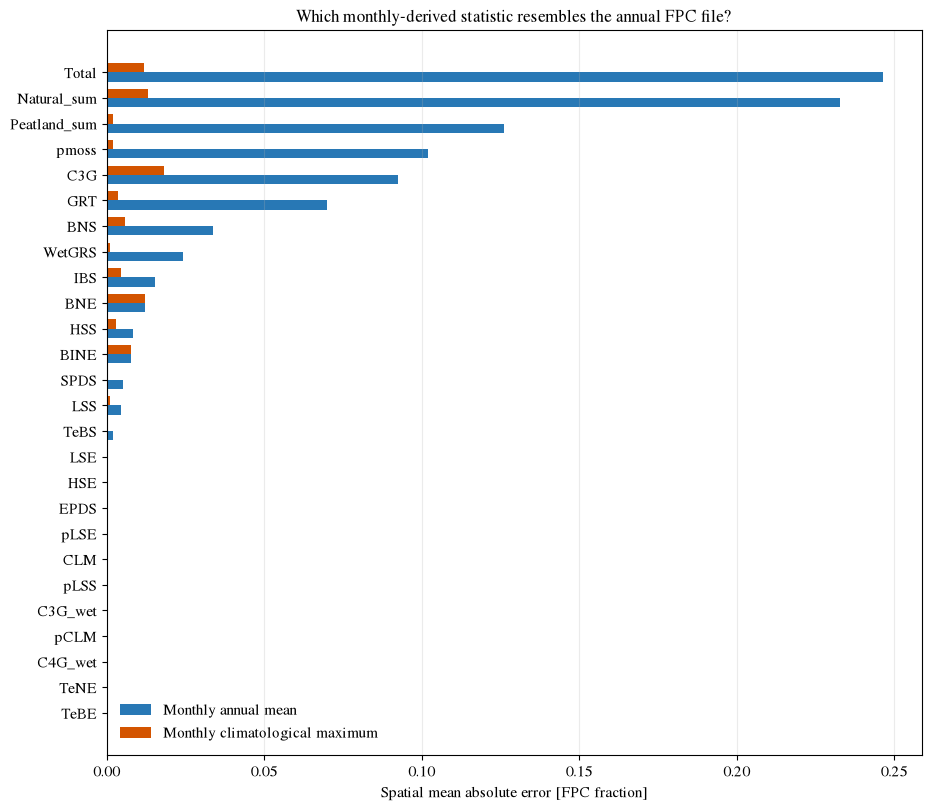

In [17]:
plot_table = summary.sort_values("MAE: monthly mean")
y = np.arange(len(plot_table))
fig, ax = plt.subplots(figsize=(9.2, 8.0), layout="constrained")
ax.barh(y - 0.18, plot_table["MAE: monthly mean"], height=0.36,
        color="#2878B5", label="Monthly annual mean")
ax.barh(y + 0.18, plot_table["MAE: monthly max"], height=0.36,
        color="#D35400", label="Monthly climatological maximum")
ax.set(yticks=y, yticklabels=plot_table["field"], xlabel="Spatial mean absolute error [FPC fraction]",
       title="Which monthly-derived statistic resembles the annual FPC file?")
ax.grid(axis="x", alpha=0.25)
ax.legend(frameon=False)
if SAVE_FIGURES:
    fig.savefig(FIGURE_DIR / "mae_monthly_mean_vs_max.png", dpi=200)
plt.show()


In [18]:
print(list(plot_table["field"]))

['TeBE', 'TeNE', 'C4G_wet', 'pCLM', 'C3G_wet', 'pLSS', 'CLM', 'pLSE', 'EPDS', 'HSE', 'LSE', 'TeBS', 'LSS', 'SPDS', 'BINE', 'HSS', 'BNE', 'IBS', 'WetGRS', 'BNS', 'GRT', 'C3G', 'pmoss', 'Peatland_sum', 'Natural_sum', 'Total']


### 6. Map the signed differences

For every selected field, the upper row shows monthly annual mean − annual file; the lower row shows monthly climatological maximum − annual file. The two rows use the same symmetric scale within each figure.


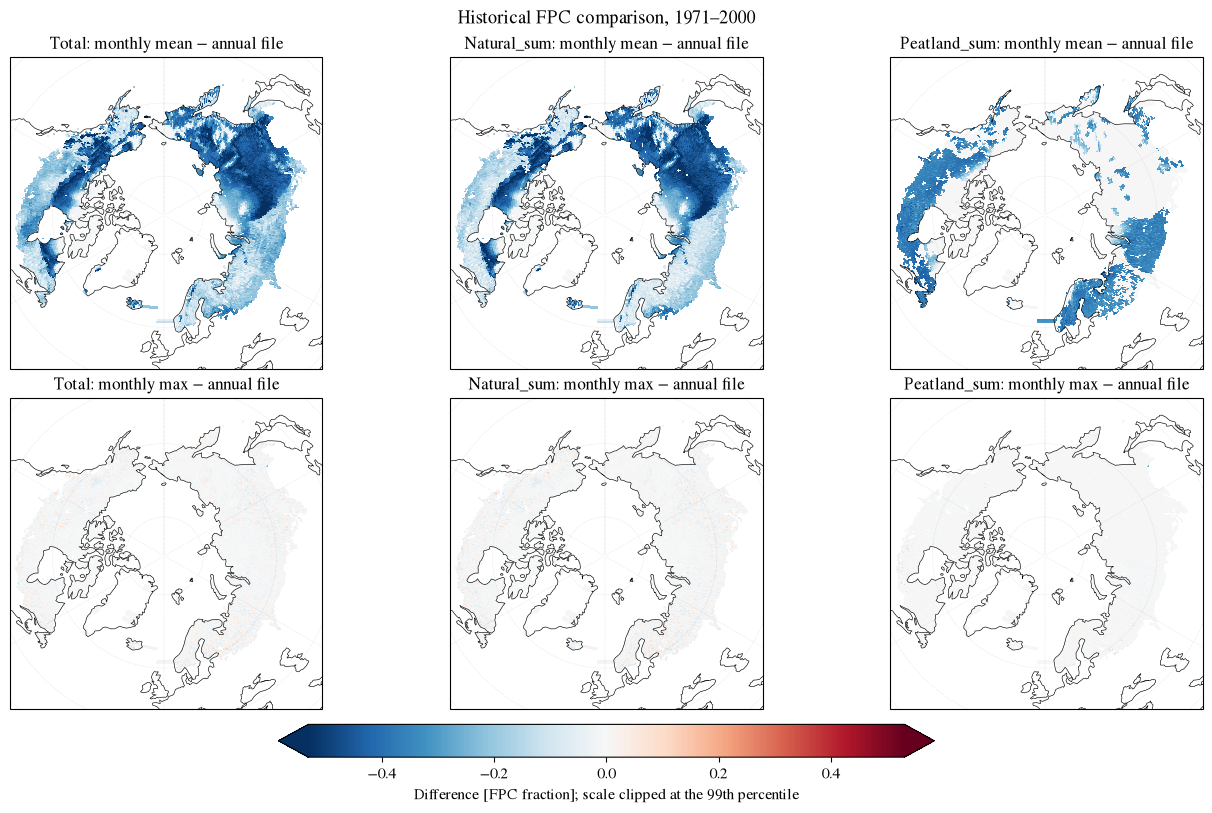

In [19]:
def difference_grid(field, statistic):
    suffix = "mean_difference" if statistic == "mean" else "max_difference"
    column = f"{field}_{suffix}"
    if column not in comparison:
        raise KeyError(f"Unknown field {field!r}; choose from {comparison_fields}")
    return comparison.pivot(index="Lat", columns="Lon", values=column).sort_index().sort_index(axis=1)


def draw_map(ax, grid, norm, title):
    if HAS_CARTOPY:
        image = ax.pcolormesh(grid.columns, grid.index, grid.to_numpy(), cmap="RdBu_r",
                              norm=norm, shading="auto", transform=ccrs.PlateCarree())
        ax.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.45)
        ax.gridlines(linewidth=0.35, color="0.5", alpha=0.4, linestyle=":")
    else:
        image = ax.pcolormesh(grid.columns, grid.index, grid.to_numpy(), cmap="RdBu_r",
                              norm=norm, shading="auto", rasterized=True)
        ax.set(xlim=(-180, 180), ylim=(45, 90), xlabel="Longitude", ylabel="Latitude")
        ax.grid(alpha=0.2, linewidth=0.4)
    ax.set_title(title)
    return image


def plot_comparison_maps(fields=MAP_FIELDS, filename="aggregate_difference_maps.png", percentile=99):
    fields = list(fields)
    grids = {(field, statistic): difference_grid(field, statistic)
             for field in fields for statistic in ["mean", "max"]}
    values = np.concatenate([
        grid.to_numpy()[np.isfinite(grid.to_numpy())] for grid in grids.values()
    ])
    vmax = max(float(np.percentile(np.abs(values), percentile)), 1e-12)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    subplot_kw = {"projection": ccrs.Orthographic(0, 90)} if HAS_CARTOPY else {}
    fig, axes = plt.subplots(int(2*len(fields)/3), 3, figsize=(4.4 * 3, 8.0* len(fields)/3),
                             subplot_kw=subplot_kw, layout="constrained", squeeze=False)
    for column, field in enumerate(fields):
        image = draw_map(axes[int(column/3), column%3], grids[(field, "mean")], norm,
                         f"{field}: monthly mean − annual file")
        draw_map(axes[int(column/3)+int(len(fields)/3), column%3], grids[(field, "max")], norm,
                 f"{field}: monthly max − annual file")

    colorbar = fig.colorbar(image, ax=axes, orientation="horizontal", shrink=0.5, pad=0.02, #6,
                            extend="both")
    colorbar.set_label("Difference [FPC fraction]; scale clipped at the 99th percentile")
    fig.suptitle(f"Historical FPC comparison, {START_YEAR}–{END_YEAR}")
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / filename, dpi=200)
    plt.show()
    #return fig


plot_comparison_maps()


### 7. Map strongly seasonal example PFTs

These fields are useful diagnostics because their foliage or cover in the supplied sample changes sharply through the year.


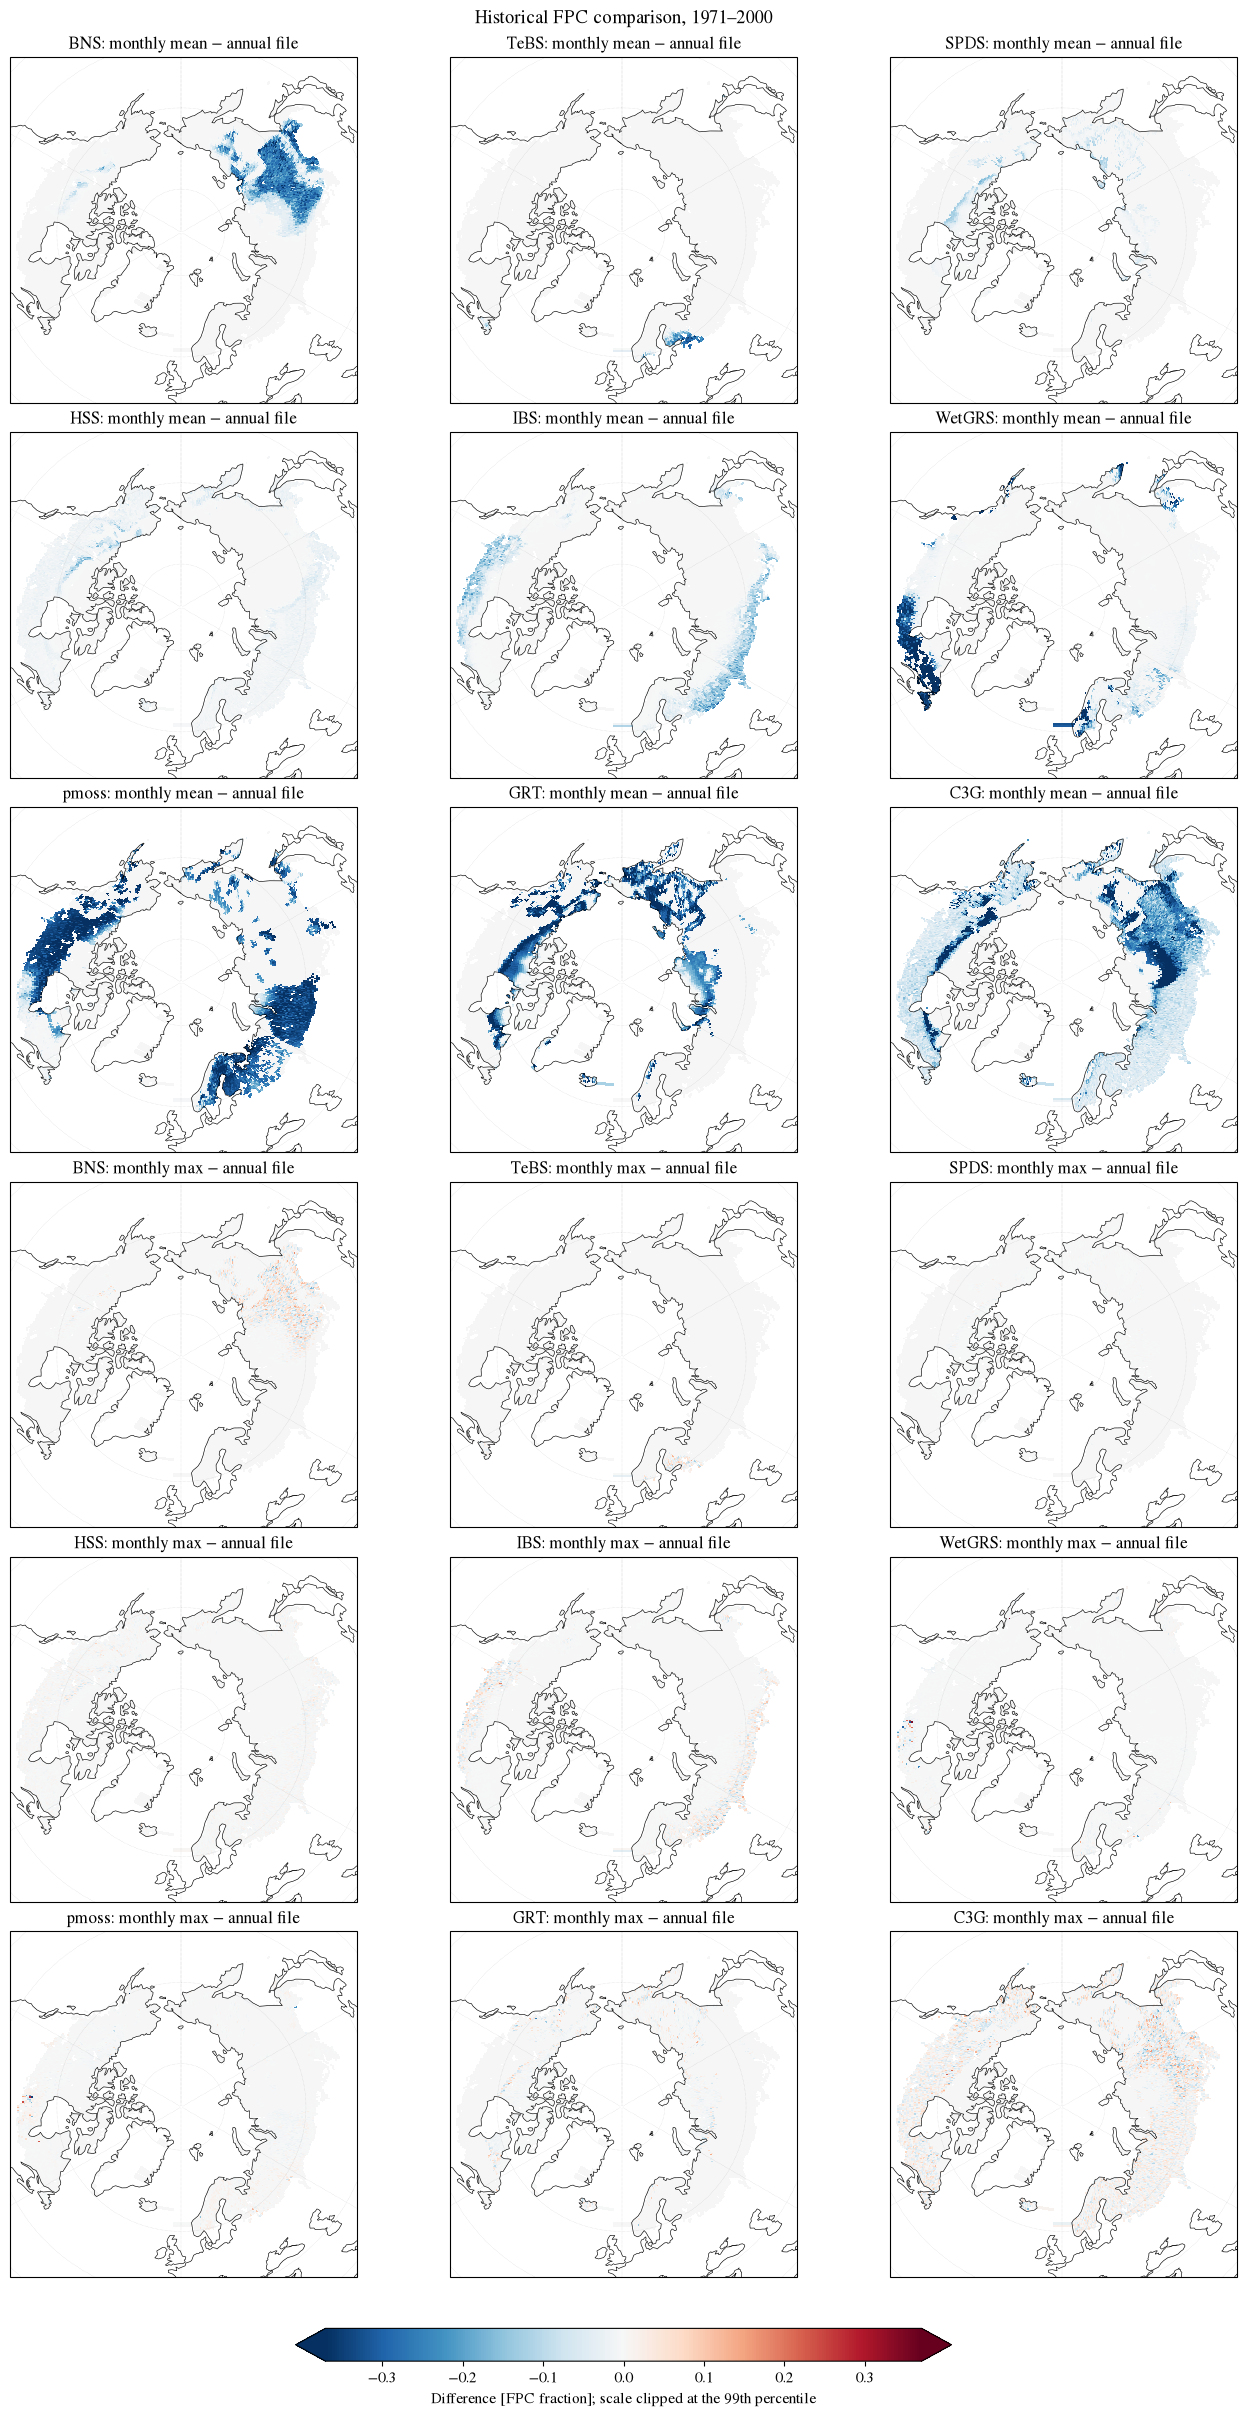

In [20]:
plot_comparison_maps(['BNS', 'TeBS', 'SPDS', 'HSS', 'IBS', 'WetGRS', 'pmoss','GRT', 'C3G'],
    # EXAMPLE_FIELDS, 
                     filename="example_difference_maps.png")

### 8. Inspect the example coordinate

This table makes the temporal definition visible at (63.25, 58.75) by listing the full climatological seasonal cycle and the annual-file values.


In [21]:
EXAMPLE_LON, EXAMPLE_LAT = 63.25, 58.75
example_cycle = monthly_climatology.loc[
    np.isclose(monthly_climatology["Lon"], EXAMPLE_LON)
    & np.isclose(monthly_climatology["Lat"], EXAMPLE_LAT),
    ["Month"] + [field for field in ["BNE", "BINE", "IBS", "C3G", "HSS", "WetGRS", "pmoss", "Total"]
                     if field in monthly_climatology],
].copy()
example_annual = annual_reference.loc[
    np.isclose(annual_reference["Lon"], EXAMPLE_LON)
    & np.isclose(annual_reference["Lat"], EXAMPLE_LAT)
]

print("Monthly climatology:")
print(example_cycle.to_string(index=False, float_format=lambda value: f"{value:.4f}"))
print("\nSupplied annual file:")
print(example_annual.to_string(index=False, float_format=lambda value: f"{value:.4f}"))


Monthly climatology:
 Month    BNE   BINE    IBS    C3G    HSS  WetGRS  pmoss  Total
     1 0.2227 0.1150 0.0000 0.0000 0.0000  0.0000 0.0000 0.2705
     2 0.2227 0.1150 0.0000 0.0000 0.0000  0.0000 0.0000 0.2705
     3 0.2227 0.1150 0.0000 0.0000 0.0000  0.0000 0.0000 0.2705
     4 0.2227 0.1150 0.0091 0.0053 0.0021  0.0017 0.0580 0.2959
     5 0.2227 0.1150 0.0974 0.0463 0.0118  0.0338 0.4005 0.4829
     6 0.2227 0.1150 0.2300 0.0718 0.0152  0.0615 0.5669 0.6510
     7 0.2227 0.1150 0.2387 0.0706 0.0152  0.0616 0.5669 0.6569
     8 0.2227 0.1150 0.2387 0.0731 0.0152  0.0616 0.5669 0.6590
     9 0.2227 0.1150 0.2387 0.0753 0.0152  0.0616 0.5669 0.6607
    10 0.2227 0.1150 0.1357 0.0411 0.0086  0.0324 0.3111 0.4883
    11 0.2227 0.1150 0.0013 0.0003 0.0001  0.0003 0.0028 0.2725
    12 0.2227 0.1150 0.0000 0.0000 0.0000  0.0000 0.0000 0.2705

Supplied annual file:
    Lon     Lat    BNE   BINE    BNS   TeNE   TeBE    IBS   TeBS    C3G    HSE    HSS    LSE    LSS    GRT   EPDS   SPDS    

## Interpretation

**The results show that `fpc1971to2000.txt` is not the calendar-year mean of the monthly FPC values. It is much closer to the maximum of the monthly climatology.**

The monthly annual mean strongly underestimates the supplied annual values:

| Field          | MAE: monthly mean | MAE: monthly maximum |
| -------------- | ----------------: | -------------------: |
| `Total`        |             0.246 |               0.0118 |
| `Natural_sum`  |             0.233 |               0.0132 |
| `Peatland_sum` |             0.126 |               0.0020 |

**Difference maps**: confirm this pattern. Monthly means produce widespread negative differences, whereas monthly maxima differ only slightly from the annual file. The best-matching month is generally July or August for seasonal PFTs, with August also providing the closest match for `Total`, `Natural_sum`, and `Peatland_sum`.

At $(63.25^\circ\mathrm{E}, 58.75^\circ\mathrm{N})$, for example:

* monthly-climatology mean `Total`: approximately 0.437;
* monthly-climatology maximum: 0.661;
* supplied annual value: 0.665.

This suggests that the annual product represents a peak-growing-season or annual-state diagnostic rather than a twelve-month average. However, it cannot be concluded that it is calculated exactly as the maximum of the monthly climatology. It could instead represent an annual maximum, a fixed reporting date, or a state recorded at another point in the LPJ-GUESS update cycle.

Note: 36 of the 16,750 annual-file cells are absent from the monthly data, and these are excluded rather than treated as zero.
